# Define Tool

LangChain me Tool ek aisa component hota hai jo LLM ko external actions perform karne deta hai.

# Tool is a wrapper around a function, API, database, or external service that allows an LLM/Agent to perform actions and retrieve real-world information beyond its training data.

# How tools fits into the agent ecosystem ?

* Problem Without Tools

Agar Agent ke paas tools na ho:

User
  ↓
Agent (LLM)
  ↓
Answer

Agent sirf apne training data se answer de sakta hai.

Example:

User: Current weather in Delhi?

Agent:

Mujhe nahi pata.

Kyuki real-time data access nahi hai.

In [ ]:
# Agent Ecosystem

            User
              ↓
           Agent
              ↓
      ┌───────┼────────┐
      ↓       ↓        ↓
 Search    Database   Calculator
  Tool       Tool       Tool
      ↓       ↓        ↓
      └───────┼────────┘
              ↓
           Agent
              ↓
          Response

Agent = Brain

Tools = Workers

# Agent Ka Workflow

* Step 1: User Question

What is the weather in Delhi?

* Step 2: Agent Thinks

Mujhe weather khud nahi pata.

Weather tool use karna chahiye.

* Step 3: Tool Call

weather_tool("Delhi")

Returns:

34°C

* Step 4: Agent Generates Answer

Delhi ka current temperature 34°C hai.

# Agent + Tools + Memory


In [ ]:
               User
                 ↓
              Agent
          ↙      ↓      ↘
     Memory    LLM     Tools
          ↘      ↓      ↙
            Final Answer

# LLM

Reasoning karta hai.

# Memory

Past conversation yaad rakhti hai.

# Tools

External actions perform karte hain.

# Agent

Sabko coordinate karta hai.

# Tools are action modules inside an agent ecosystem. The agent uses the LLM to decide when and which tool to invoke, executes the tool, receives the result, and then generates the final response for the user.

# Built-in Tools

LangChain me Built-in Tools wo ready-made tools hote hain jo common tasks ke liye pehle se available hote hain. Tumhe khud function likhne ki zarurat nahi padti.



# 1. Search Tool

Internet se information laata hai.



In [ ]:
from langchain.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()
search.run("Latest AI news")

# Use case:

Current events

Real-time information

Web search

# 2. Wikipedia Tool

Wikipedia se information fetch karta hai.

In [ ]:
from langchain.tools import WikipediaQueryRun

# Use case:

General knowledge

Historical facts

Person/company information

# 3. Python REPL Tool

Python code execute karta hai.



In [ ]:
from langchain_experimental.tools import PythonREPLTool

# Use case:

Calculations

Data analysis

Math problems

# 4. Requests Tool
HTTP API call kar sakta hai.

In [ ]:
RequestsGetTool
RequestsPostTool

# Use case:

REST APIs

External services

Fetching JSON data

# 5. SQL Database Tool

Database query karne ke liye.

In [ ]:
SQLDatabaseToolkit

# Use case:

SELECT * FROM customers;

# 6. File Management Tool



In [ ]:
ReadFileTool
WriteFileTool
ListDirectoryTool

# Use case:

Read files

Create files

Manage folders

# 7. Shell / Terminal Tool

In [ ]:
ShellTool

# Use case:

Run terminal commands

* Example:

ls

pwd

# 8. Gmail Tool

Gmail ke saath interact kar sakta hai.

Use case:

Read emails

Send emails

# 9. Google Drive Tool

Use case:

Read documents

Upload files

Manage Drive data

# 10. Vector Database Tools

For RAG applications.

Examples:

Chroma,
FAISS,
Pinecone

Use case:

Semantic search

Document retrieval

Chat with PDFs

In [ ]:
# Built-in Tools in Agent Ecosystem
                    Agent
                       │
      ┌────────────────┼────────────────┐
      │                │                │
   Search Tool     Python Tool      SQL Tool
      │                │                │
      └────────────────┼────────────────┘
                       │
                    Result

# Custom Tools

Aisa tool jo tum khud banate ho jab built-in tools tumhari requirement fulfill nahi karte.

Built-in Tool = Ready-made

Custom Tool = User-made

# Example

Maan lo tumhare paas ek e-commerce app hai aur tum chahte ho:

"Check product stock"

LangChain me iska built-in tool nahi hai.

Toh tum apna custom tool banaoge.

In [ ]:
from langchain.tools import tool

@tool
def check_stock(product_id: str):
    """Check stock availability of a product."""

    return "15 items available"

# Tool Structure

Har custom tool me 3 cheeze hoti hain:

# 1. Name

check_stock
# 2. Description
"""Check stock availability of a product."""

Ye description Agent ko batati hai ki tool kab use karna hai.

# 3. Function Logic
return "15 items available"

# A Custom Tool is a user-defined function wrapped as a LangChain tool that enables an agent to perform domain-specific actions, interact with APIs, databases, or business logic beyond the built-in tools.

# Ways to create a custom tools

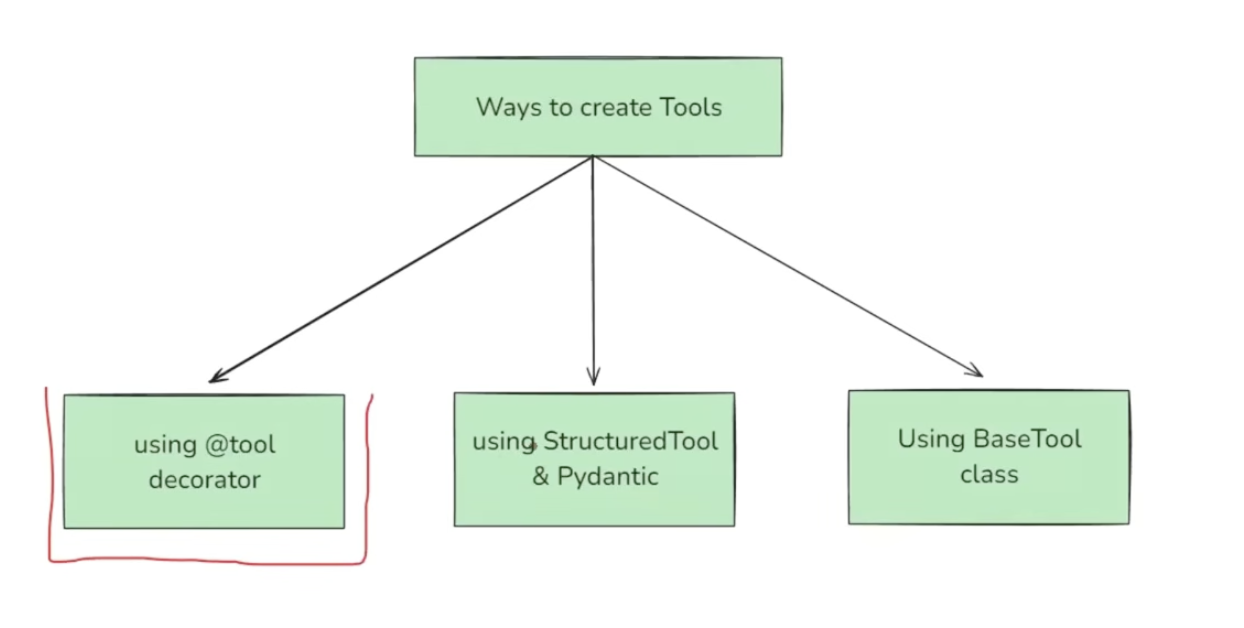

# 1. Using @tool Decorator



In [ ]:
from langchain.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers."""
    return a * b

# Use:

multiply.invoke({"a": 5, "b": 4})

Output:

20

✅ Small functions ke liye best

#2. Using StructuredTool

Jab multiple parameters aur validation chahiye.

StructuredTool ek aisa tool hai jo multiple inputs (arguments) ko properly handle karta hai aur unki validation bhi karta hai.

  # Problem with Simple @tool
from langchain.tools import tool

@tool

def multiply(a: int, b: int):

    return a * b

Ye simple cases me theek hai.

Lekin agar function me bahut saare parameters hon:

def book_flight(
    source,
    destination,
    date,
    passengers
):
    pass

Toh structured input ki zaroorat padti hai.

Isi liye StructuredTool use karte hain.

In [ ]:
from langchain.tools import StructuredTool

def multiply(a: int, b: int):
    return a * b

tool = StructuredTool.from_function(
    func=multiply,
    name="multiply",
    description="Multiply two numbers"
)

# Use:

tool.invoke({"a": 5, "b": 4})

✅ Production applications me kaafi use hota hai.

# 3. Inheriting BaseTool

Jab custom behavior chahiye.

BaseTool LangChain ke saare tools ki parent/base class hoti hai.



# Why BaseTool?

@tool aur StructuredTool simple cases ke liye hain.

Lekin agar tumhe:

Custom validation

Custom error handling

Sync + Async execution

Enterprise-level tools

Complex business logic

chahiye ho, to BaseTool use karte hain.

In [ ]:
from langchain.tools import BaseTool

class MultiplyTool(BaseTool):
    name = "multiply"
    description = "Multiply two numbers"

    def _run(self, a: int, b: int):
        return a * b

 # Use:

tool = MultiplyTool()

tool.invoke({"a": 5, "b": 4})

✅ Complex enterprise tools ke liye

# Tool Kits

Related tools ka collection (group).

Simple words me:

Tool = Ek single tool

Toolkit = Multiple related tools ka package

* Example

Agar tum database ke saath kaam kar rahe ho:

Instead of creating:

Tool 1 → List Tables

Tool 2 → Get Schema

Tool 3 → Run SQL Query

Tool 4 → Validate Query

LangChain ye sab ek SQL Toolkit me provide kar deta hai.

SQL Toolkit
   ├── List Tables Tool
   ├── Schema Tool
   ├── Query Tool
   └── Query Checker Tool

# Why Toolkit?

Without Toolkit:

tool1,
tool2,
tool3,
tool4,
tool5

Har tool manually manage karna padega.

With Toolkit:

toolkit.get_tools()

Saare tools ek saath mil jaate hain.

In [ ]:
# Architecture

                    Agent
                       │
                SQL Toolkit
                       │
      ┌────────────────┼────────────────┐
      │                │                │
 List Tables      Get Schema       Run Query
      │                │                │
      └────────────────┼────────────────┘
                       │
                    Database

# Toolkit Creation



In [ ]:
class EcommerceToolkit:

    def get_tools(self):
        return [
            check_inventory_tool,
            place_order_tool,
            cancel_order_tool
        ]


Agent ko:

tools = toolkit.get_tools()

de diya jaata hai.

# A Toolkit in LangChain is a collection of related tools bundled together to provide a complete capability domain (such as SQL, Gmail, GitHub, or file management) that can be easily supplied to an agent.